In [25]:
"""
NB06_Altitude_Drift_Metrics (Conservative and Phase-Aware)

Purpose
-------
1) Load per-encounter Δe₂D and net results from NB05.
2) Present the conservative altitude drift Δh_max (already computed in NB05).
3) Compute PHASE-AWARE radial perturbation Δr(ν) for each encounter
   and for the net, using the projection form from Section 4.4:
     Δr(ν) = -F(e,p) * (Δe · r̂(ν))
           = -F * (Δe_p cos ν + Δe_q sin ν)
4) Identify periapsis-specific altitude change predictions.
5) Produce publication-quality summary plots.

Key distinction (Section 4.4)
-----------------------------
- Conservative bound: Δh_max = F * ||Δe||  (phase-independent worst case)
- Phase-aware:        Δr(ν)  = -F * (Δe · r̂(ν))  (depends on where you evaluate)
  The phase-aware form typically gives LESS conservative predictions.

Dependencies: NB05 artifact in ./artifacts/
"""

from __future__ import annotations

import json
import numpy as np
from pathlib import Path
from datetime import datetime, timezone

import matplotlib.pyplot as plt

In [26]:
# ============================================================
# Cell 1 : Auto-discover NB05 Artifact
# ============================================================
ART_DIR = Path("./artifacts")

nb05_files = sorted(ART_DIR.glob("deltae_NB05_*.npz"))
if not nb05_files:
    raise FileNotFoundError("No NB05 artifact found. Run NB05 first.")

NB05_NPZ = nb05_files[-1]

RUN_TAG  = datetime.now(timezone.utc).strftime("NB06_%Y%m%dT%H%M%SZ")
OUT_NPZ  = ART_DIR / f"drift_metrics_{RUN_TAG}.npz"
OUT_JSON = ART_DIR / f"drift_metrics_{RUN_TAG}.json"

print(f"NB05 input : {NB05_NPZ}")
print(f"Output     : {OUT_NPZ}")
print(f"Output     : {OUT_JSON}")

NB05 input : artifacts\deltae_NB05_20260316T125355Z.npz
Output     : artifacts\drift_metrics_NB06_20260316T125735Z.npz
Output     : artifacts\drift_metrics_NB06_20260316T125735Z.json


In [27]:
# ============================================================
# Cell 2 : Load NB05 Data
# ============================================================
nb5 = np.load(NB05_NPZ, allow_pickle=False)

t    = nb5["t"]
segs = nb5["segs"].astype(int)   # (K, 2)

# Per-encounter eccentricity results (from corrected NB05)
de2d      = nb5["de2d"]          # (K, 2)  [de_p, de_q]
de2d_norm = nb5["de2d_norm"]     # (K,)
de2d_net  = nb5["de2d_net"]      # (2,)

# Pre-computed altitude drift from NB05
dh_max_per = nb5["dh_max_per"]   # (K,) km
dh_max_net = float(nb5["dh_max_net"])  # scalar km
F_amp      = float(nb5["F_amp"])       # km
eta_cancel = float(nb5["eta_cancel"])

# Canonical anomaly (from fixed p/q basis)
if "nu_pq" in nb5:
    nu = nb5["nu_pq"]
    _nu_src = "nu_pq"
elif "nu_grid" in nb5:
    nu = nb5["nu_grid"]
    _nu_src = "nu_grid"
else:
    raise KeyError("No anomaly grid found in NB05 artifact.")

# Basis vectors
p_hat = nb5["p_hat"]   # (3,)
q_hat = nb5["q_hat"]   # (3,)

meta_nb5 = json.loads(str(nb5["meta_json"])) if "meta_json" in nb5 else {}

M = t.size
K = segs.shape[0]
de2d_net_norm = float(np.linalg.norm(de2d_net))
sum_dh = float(np.sum(dh_max_per))

print(f"M = {M}   K = {K} encounters")
print(f"F(e,p)      = {F_amp:.4f} km")
print(f"eta_cancel  = {eta_cancel:.4f}")
print(f"nu source   = {_nu_src}")
print(f"\nConservative bounds (from NB05):")
print(f"  dh_max per encounter [m] : {(dh_max_per*1000).round(2)}")
print(f"  dh_max_net [m]           : {dh_max_net*1000:.2f}")
print(f"  sum dh_max_i [m]         : {sum_dh*1000:.2f}")

M = 4000   K = 4 encounters
F(e,p)      = 1787.4000 km
eta_cancel  = 0.1012
nu source   = nu_pq

Conservative bounds (from NB05):
  dh_max per encounter [m] : [320.1  151.78 123.6  307.01]
  dh_max_net [m]           : 91.37
  sum dh_max_i [m]         : 902.49


In [28]:
# ============================================================
# Cell 3 : Phase-Aware Radial Perturbation Δr(ν)
# ============================================================
# Section 4.4 (projection form):
#   Δr(ν) ≈ -p / (1 + e·r̂(ν))^2 * (Δe · r̂(ν))
#
# For the conservative bound (Cauchy-Schwarz), we used
#   |Δr| ≤ F * ||Δe||   with  F = p/(1-e)^2
#
# For phase-aware evaluation, the projection onto r̂(ν) is:
#   Δe · r̂(ν) = Δe_p cos ν + Δe_q sin ν
#
# And for small e (circular reference):
#   Δr(ν) ≈ -a * (Δe_p cos ν + Δe_q sin ν)
#
# NOTE the MINUS sign: a positive Δe_p means periapsis shifts,
# and the radius DECREASES at the new periapsis location.

cos_nu = np.cos(nu)
sin_nu = np.sin(nu)

def segment_indices(a: int, b: int, M: int) -> np.ndarray:
    if a <= b:
        return np.arange(a, b + 1)
    return np.concatenate([np.arange(a, M), np.arange(0, b + 1)])

# Per-encounter phase-aware Δr(ν) over the full orbit
#   dr_i[k, j] = -F * (de_p[k]*cos(nu[j]) + de_q[k]*sin(nu[j]))
dr_i = -F_amp * (de2d[:, [0]] * cos_nu[None, :] + de2d[:, [1]] * sin_nu[None, :])  # (K, M)

# Net phase-aware Δr(ν)
dr_net = -F_amp * (float(de2d_net[0]) * cos_nu + float(de2d_net[1]) * sin_nu)  # (M,)

print(f"Phase-aware Δr computed.")
print(f"  dr_net range [km]: [{dr_net.min():.6f}, {dr_net.max():.6f}]")
print(f"  dr_net range [m] : [{dr_net.min()*1000:.2f}, {dr_net.max()*1000:.2f}]")
print(f"  max|dr_net| [m]  : {np.abs(dr_net).max()*1000:.2f}")
print(f"  (conservative bound was {dh_max_net*1000:.2f} m)")

Phase-aware Δr computed.
  dr_net range [km]: [-0.091368, 0.091368]
  dr_net range [m] : [-91.37, 91.37]
  max|dr_net| [m]  : 91.37
  (conservative bound was 91.37 m)


In [29]:
# ============================================================
# Cell 4 : Per-Encounter Phase-Aware Metrics
# ============================================================
# For each encounter, find:
#   - Phase-aware Δr extrema within the encounter window
#   - Location (ν, t) of those extrema
#   - Compare with the conservative bound

enc_metrics = []

for i in range(K):
    a, b = int(segs[i, 0]), int(segs[i, 1])
    idx = segment_indices(a, b, M)

    # Phase-aware Δr within the encounter window
    dr_enc = dr_i[i, idx]
    j_max_local = int(np.argmax(dr_enc))
    j_min_local = int(np.argmin(dr_enc))
    j_max_global = idx[j_max_local]
    j_min_global = idx[j_min_local]

    enc_metrics.append({
        "id":              int(i),
        "start":           int(a),
        "end":             int(b),
        "length":          int(idx.size),
        "de_p":            float(de2d[i, 0]),
        "de_q":            float(de2d[i, 1]),
        "de2d_norm":       float(de2d_norm[i]),
        # Conservative
        "dh_max_km":       float(dh_max_per[i]),
        "dh_max_m":        float(dh_max_per[i] * 1000),
        # Phase-aware (within encounter window)
        "dr_max_km":       float(dr_enc.max()),
        "dr_min_km":       float(dr_enc.min()),
        "dr_max_m":        float(dr_enc.max() * 1000),
        "dr_min_m":        float(dr_enc.min() * 1000),
        "nu_at_dr_max":    float(nu[j_max_global]),
        "nu_at_dr_min":    float(nu[j_min_global]),
    })

# Net phase-aware extrema (over full orbit)
j_net_max = int(np.argmax(dr_net))
j_net_min = int(np.argmin(dr_net))

net_metrics = {
    "de_p_net":           float(de2d_net[0]),
    "de_q_net":           float(de2d_net[1]),
    "de2d_net_norm":      de2d_net_norm,
    "dh_max_net_km":      dh_max_net,
    "dh_max_net_m":       dh_max_net * 1000,
    "dr_net_max_km":      float(dr_net.max()),
    "dr_net_min_km":      float(dr_net.min()),
    "dr_net_max_m":       float(dr_net.max() * 1000),
    "dr_net_min_m":       float(dr_net.min() * 1000),
    "nu_at_dr_net_max":   float(nu[j_net_max]),
    "nu_at_dr_net_min":   float(nu[j_net_min]),
    "eta_cancel":         eta_cancel,
}

# --- Print summary ---
print(f"{'='*80}")
print(f"  PER-ENCOUNTER METRICS: Conservative vs Phase-Aware")
print(f"{'='*80}")
print(f"{'ID':>3s}  {'Len':>4s}  {'dh_max[m]':>10s}  {'dr_min[m]':>10s}  {'dr_max[m]':>10s}  {'ratio':>6s}")
for r in enc_metrics:
    # ratio = max|phase-aware| / conservative
    max_phase = max(abs(r['dr_min_m']), abs(r['dr_max_m']))
    ratio = max_phase / r['dh_max_m'] if r['dh_max_m'] > 0 else 0
    print(f"{r['id']:3d}  {r['length']:4d}  {r['dh_max_m']:10.2f}  {r['dr_min_m']:+10.2f}  {r['dr_max_m']:+10.2f}  {ratio:6.3f}")

print(f"\n  Net:")
print(f"    Conservative dh_max_net = {net_metrics['dh_max_net_m']:.2f} m")
print(f"    Phase-aware  dr_min     = {net_metrics['dr_net_min_m']:+.2f} m  at nu={net_metrics['nu_at_dr_net_min']:.3f} rad")
print(f"    Phase-aware  dr_max     = {net_metrics['dr_net_max_m']:+.2f} m  at nu={net_metrics['nu_at_dr_net_max']:.3f} rad")

  PER-ENCOUNTER METRICS: Conservative vs Phase-Aware
 ID   Len   dh_max[m]   dr_min[m]   dr_max[m]   ratio
  0   129      320.10      +29.39      +92.46   0.289
  1    50      151.78     +119.12     +126.00   0.830
  2    50      123.60      -92.89      -86.35   0.752
  3   140      307.01      -19.45      +47.38   0.154

  Net:
    Conservative dh_max_net = 91.37 m
    Phase-aware  dr_min     = -91.37 m  at nu=0.256 rad
    Phase-aware  dr_max     = +91.37 m  at nu=3.398 rad


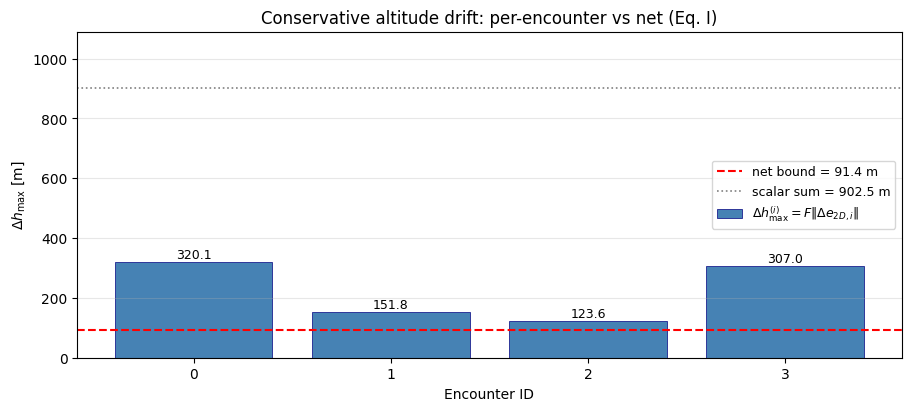

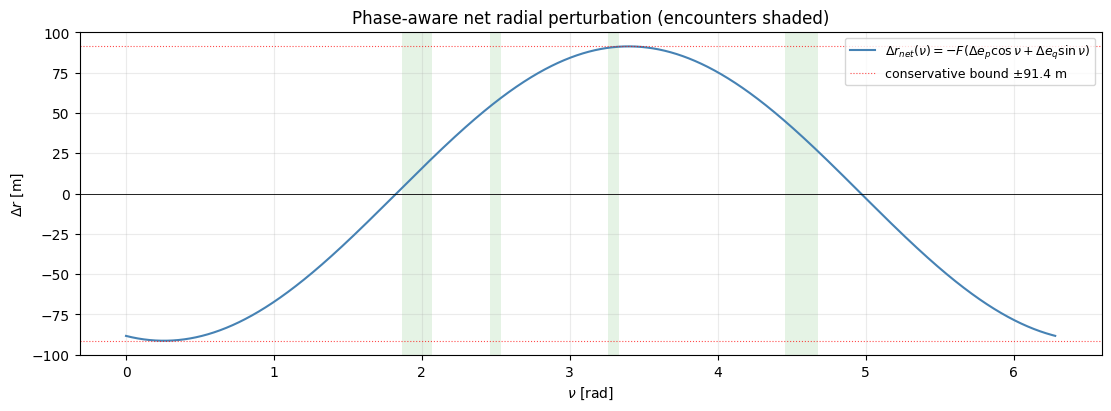

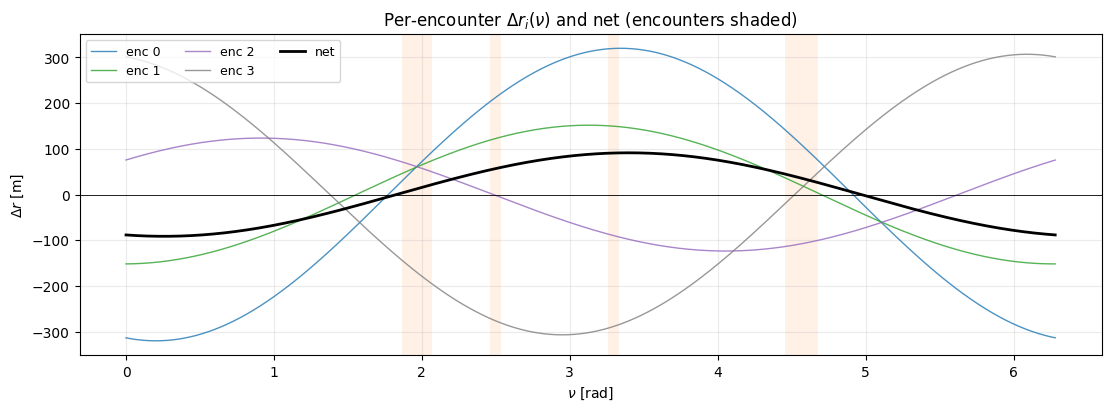

In [30]:
# ============================================================
# Cell 5 : Plots
# ============================================================

def shade_encounters_nu(ax, segs, nu, M, color="tab:orange", alpha=0.15):
    for (a, b) in segs:
        a, b = int(a), int(b)
        if a <= b:
            ax.axvspan(nu[a], nu[b], color=color, alpha=alpha, lw=0)
        else:
            ax.axvspan(nu[a], nu[-1], color=color, alpha=alpha, lw=0)
            ax.axvspan(nu[0], nu[b], color=color, alpha=alpha, lw=0)

# --- Plot 1: Conservative Δh_max bars (per encounter + net + sum) ---
fig, ax = plt.subplots(figsize=(9, 4.0), constrained_layout=True)
x = np.arange(K)
bars = ax.bar(x, dh_max_per * 1000, color="steelblue", edgecolor="navy", lw=0.5,
              label=r"$\Delta h_{\max}^{(i)} = F\|\Delta e_{2D,i}\|$")
for bar, val in zip(bars, dh_max_per * 1000):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            f"{val:.1f}", ha="center", va="bottom", fontsize=9)

ax.axhline(dh_max_net * 1000, color="red", ls="--", lw=1.5,
           label=f"net bound = {dh_max_net*1000:.1f} m")
ax.axhline(sum_dh * 1000, color="gray", ls=":", lw=1.2,
           label=f"scalar sum = {sum_dh*1000:.1f} m")

ax.set_xlabel("Encounter ID")
ax.set_ylabel(r"$\Delta h_{\max}$ [m]")
ax.set_title("Conservative altitude drift: per-encounter vs net (Eq. I)")
ax.set_xticks(x)
ax.set_ylim(0, ax.get_ylim()[1] * 1.15)
ax.grid(True, axis="y", alpha=0.3)
ax.legend(loc="best", fontsize=9)
plt.show()

# --- Plot 2: Phase-aware net Δr(ν) over full orbit ---
fig, ax = plt.subplots(figsize=(11, 4.0), constrained_layout=True)
ax.plot(nu, dr_net * 1000, lw=1.5, color="steelblue",
        label=r"$\Delta r_{net}(\nu) = -F(\Delta e_p \cos\nu + \Delta e_q \sin\nu)$")
shade_encounters_nu(ax, segs, nu, M, color="tab:green", alpha=0.12)
ax.axhline(0, color="k", lw=0.6)
ax.axhline(+dh_max_net * 1000, color="red", ls=":", lw=0.8, alpha=0.7,
           label=f"conservative bound ±{dh_max_net*1000:.1f} m")
ax.axhline(-dh_max_net * 1000, color="red", ls=":", lw=0.8, alpha=0.7)
ax.set_xlabel(r"$\nu$ [rad]")
ax.set_ylabel(r"$\Delta r$ [m]")
ax.set_title("Phase-aware net radial perturbation (encounters shaded)")
ax.grid(True, alpha=0.25)
ax.legend(loc="best", fontsize=9)
plt.show()

# --- Plot 3: Per-encounter Δr_i(ν) overlay + net ---
fig, ax = plt.subplots(figsize=(11, 4.0), constrained_layout=True)
colors_enc = plt.cm.tab10(np.linspace(0, 0.7, K))
for i in range(K):
    ax.plot(nu, dr_i[i] * 1000, lw=1.0, alpha=0.8, color=colors_enc[i],
            label=f"enc {i}")
ax.plot(nu, dr_net * 1000, color="k", lw=2.0, label="net", zorder=5)
shade_encounters_nu(ax, segs, nu, M, color="tab:orange", alpha=0.10)
ax.axhline(0, color="k", lw=0.6)
ax.set_xlabel(r"$\nu$ [rad]")
ax.set_ylabel(r"$\Delta r$ [m]")
ax.set_title(r"Per-encounter $\Delta r_i(\nu)$ and net (encounters shaded)")
ax.grid(True, alpha=0.25)
ax.legend(loc="best", ncols=3, fontsize=9)
plt.show()

In [31]:
# ============================================================
# Cell 6 : Save Artifacts
# ============================================================
meta = {
    "run_tag":          RUN_TAG,
    "input_nb05_npz":   str(NB05_NPZ),
    "nu_source":        _nu_src,
    "F_km":             F_amp,
    "phase_aware_formula": "dr(nu) = -F * (de_p*cos(nu) + de_q*sin(nu))  [Section 4.4]",
    "conservative_formula": "dh_max = F * ||de2d||   [Section 4.5]",
    "net_metrics":      net_metrics,
    "nb05_meta_excerpt": {
        "mu_km3_s2":     meta_nb5.get("mu_km3_s2", None),
        "orbital_params": meta_nb5.get("orbital_params", None),
        "basis":         meta_nb5.get("basis", None),
    },
}

np.savez(
    OUT_NPZ,
    t=t,
    nu=nu,
    segs=segs,
    F_km=F_amp,
    # Eccentricity results (from NB05)
    de2d=de2d,
    de2d_net=de2d_net,
    de2d_norm=de2d_norm,
    # Conservative bounds
    dh_max_per=dh_max_per,
    dh_max_net=dh_max_net,
    dh_max_sum=sum_dh,
    eta_cancel=eta_cancel,
    # Phase-aware
    dr_i=dr_i,
    dr_net=dr_net,
    # Meta
    meta_json=json.dumps(meta),
)

OUT_JSON.write_text(
    json.dumps({"meta": meta, "encounters": enc_metrics}, indent=2),
    encoding="utf-8"
)

print(f"Saved: {OUT_NPZ}")
print(f"Saved: {OUT_JSON}")
print(f"\n--- NB06 complete ---")

Saved: artifacts\drift_metrics_NB06_20260316T125735Z.npz
Saved: artifacts\drift_metrics_NB06_20260316T125735Z.json

--- NB06 complete ---
